# TimeGAN v10 — QuantileTransformer

## El diagnóstico unificado

El G loss ha sido **~2.19 constante en todas las versiones v4→v7**. Al calcular
matemáticamente qué logit produce ese valor en BCE: `log(1+e²) ≈ 2.127` por término,
lo que significa que el discriminador produce output ≈ −2 para **todos** los
sintéticos desde el primer batch. El generador nunca recibe gradiente útil.

La razón no es el clip, ni las features constantes, ni la bimodalidad FIT.
Es un **mismatch distribucional fundamental**:

- El **Generador** parte de ruido `z ~ U(0,1)` → produce `E_hat` con distribución uniforme.
- El **Embedder** mapea datos reales `x` → produce `H_real` con distribución **concentrada**
  (spikes en bordes por MinMaxScaler, clusters por la estructura de los datos).
- El **Discriminador** distingue `H_real` de `E_hat` trivialmente por su distribución marginal,
  sin necesitar aprender ninguna estructura temporal.

Cualquier scaler que preserve spikes en bordes (`[0,1]` o `[-4, 138]`) crea este problema.

## La solución: QuantileTransformer

`QuantileTransformer(output_distribution='uniform')` mapea **cualquier distribución**
a `U(0,1)` exactamente, por construcción. No importa si los datos tienen spikes,
son bimodales, asimétricos o tienen outliers.

Resultado:
- Los datos transformados tienen distribución **exactamente uniforme** en `[0,1]`.
- El Embedder produce `H_real` con distribución uniforme.
- El Generador produce `E_hat` con distribución uniforme (por ruido `U(0,1)`).
- El Discriminador **ya no puede distinguirlos por distribución** → debe aprender
  la estructura temporal → el G recibe gradiente útil → converge.

El `Recovery` sigue siendo lineal (sin activación), y el `inverse_transform`
del `QuantileTransformer` devuelve los datos a escala física para el detector.

## Resumen de cambios v8 → v9

| | v7 | v8 |
|---|---|---|
| Scaler TimeGAN | QuantileTransformer(uniform) | QuantileTransformer(uniform) — igual |
| Features GAN | 14 (AIT+LIT+PIT+DPIT) | **14 — igual** |
| FITs | Empírico condicional | **Empírico condicional — igual** |
| Recovery | Lineal | **Lineal — igual** |
| Clip post-generación | `np.clip(x, 0, 1)` | **No necesario** |


## Cambios v8 → v9 (historial)
*(ver versión anterior)*

## Cambios v9 → v10
| | v8 | v9 |
|---|---|---|
| gamma | 1 | **0.1** — menos señal adversarial sobre e_hat |
| D lr | 1e-4 | **5e-5** — D aprende 2x más lento |
| h_sup en G | `supervisor(h_real)` con grad | **`no_grad`** — supervisor no se actualiza sobre reales |
| LR schedulers | No | **ReduceLROnPlateau** (G y D) |

| | v9 | v10 |
|---|---|---|
| gamma | 0.1 | **0.5** — D colapsó, necesita más señal |
| D lr | 5e-5 | **1e-4** — restaurado, D_STEPS compensa |
| D_STEPS | 1 | **2** — D actualiza igual que G |
| Gradient penalty | No | **GP_LAMBDA=10** — evita colapso D |
| Feature matching | No | **fm_loss** — generador replica estadísticas latentes |

In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5

# Features continuas / bimodales (igual que v7)
FIT_COLS      = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"GAN continuas (QuantileTransformer): {len(GAN_CONT_COLS)} → {GAN_CONT_COLS}")
print(f"FIT (empírico condicional):          {len(FIT_COLS)}")


Window: 60 | Stride TimeGAN: 5
GAN continuas (QuantileTransformer): 14 → ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
FIT (empírico condicional):          9


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}

common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df     = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS      if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"GAN continuas final: {len(GAN_CONT_COLS)}")


GAN continuas final: 14


In [5]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


## Escalado con QuantileTransformer

**Por qué QuantileTransformer y no MinMaxScaler/StandardScaler:**

El `QuantileTransformer(output_distribution='uniform')` mapea los datos a
distribución **exactamente uniforme** en `[0,1]`. Esto significa:

- No hay spikes en `0.0` ni en `1.0` — por construcción, cada cuantil
  ocupa la misma fracción del espacio transformado.
- No importa si los datos son bimodales, tienen outliers o son asimétricos.
- El `n_quantiles=1000` garantiza alta resolución para datasets de ~19k filas.

**Verificación clave:** el porcentaje de valores exactamente `0.0` o `1.0`
debería ser próximo a `0%` (puede ser `< 0.1%` por el límite del transformador).


In [6]:
# Scaler para el detector (StandardScaler, sin cambios)
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

# ---------------------------------------------------------------
# FIX v8: QuantileTransformer para las features GAN
# ---------------------------------------------------------------
train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)

qt = QuantileTransformer(
    n_quantiles=1000,
    output_distribution="uniform",
    subsample=None,          # usar todos los datos de train
    random_state=SEED
)
qt.fit(train_gan_cont)

# Verificar la distribución transformada
sample_qt = qt.transform(train_gan_cont)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer → rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Exactamente 0.0: {pct0:.3f}%  (v7: 6.59%, v6: 19.1%)")
print(f"Exactamente 1.0: {pct1:.3f}%")
print(f"Media: {sample_qt.mean():.4f} (esperada ~0.5 para distribución uniforme)")
print(f"Std:  {sample_qt.std():.4f} (esperada ~0.289 para U(0,1))")

if pct0 + pct1 < 0.5:
    print("\n✅  Distribución uniforme — el mismatch distribucional está resuelto")
elif pct0 + pct1 < 2.0:
    print("\n⚠️  Casi uniforme — aceptable")
else:
    print("\n❌  Aún hay extremos — revisar n_quantiles")


QuantileTransformer → rango: [0.000000, 1.000000]
Exactamente 0.0: 0.029%  (v7: 6.59%, v6: 19.1%)
Exactamente 1.0: 1.600%
Media: 0.5017 (esperada ~0.5 para distribución uniforme)
Std:  0.2911 (esperada ~0.289 para U(0,1))

⚠️  Casi uniforme — aceptable


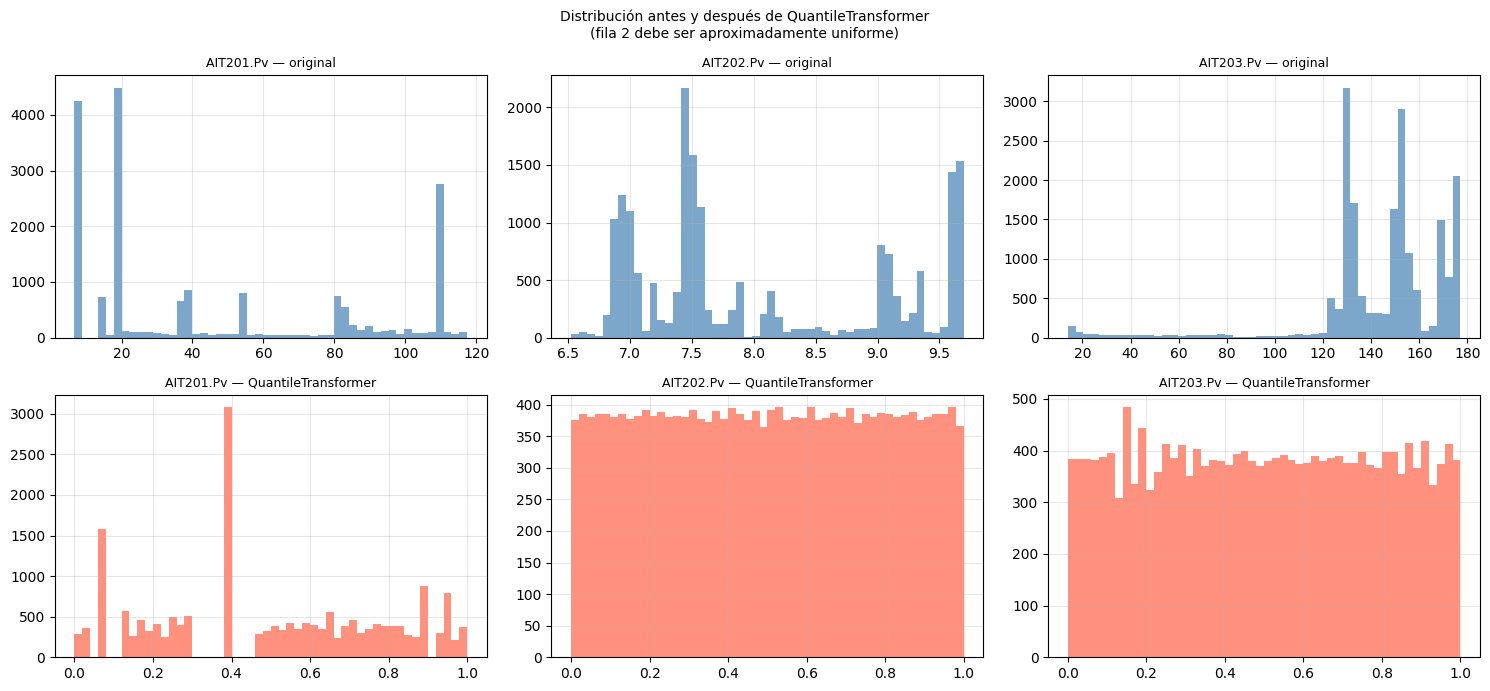

In [7]:
# Visualizar distribución antes y después para 3 features
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for idx, col in enumerate(GAN_CONT_COLS[:3]):
    original = train_gan_cont[col].values
    transformed = sample_qt[:, idx]
    axes[0, idx].hist(original, bins=50, alpha=0.7, color='steelblue')
    axes[0, idx].set_title(f"{col} — original", fontsize=9)
    axes[0, idx].grid(True, alpha=0.3)
    axes[1, idx].hist(transformed, bins=50, alpha=0.7, color='tomato')
    axes[1, idx].set_title(f"{col} — QuantileTransformer", fontsize=9)
    axes[1, idx].grid(True, alpha=0.3)
plt.suptitle("Distribución antes y después de QuantileTransformer\n(fila 2 debe ser aproximadamente uniforme)",
             fontsize=10)
plt.tight_layout()
plt.show()


In [8]:
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_vals = qt.transform(df_part[GAN_CONT_COLS])
        scaled_gan_by_file[name][subset] = pd.DataFrame(
            scaled_vals, columns=GAN_CONT_COLS, index=df_part.index
        )
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogos empíricos (FITs y discretas)


In [9]:
train_fit_global = pd.concat(
    [raw_fit_by_file[name]["train"] for name in raw_fit_by_file], axis=0
).reset_index(drop=True)

train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

fit_empirical = {}
for col in FIT_COLS:
    series   = train_fit_global[col].dropna()
    p_zero   = (series == 0.0).mean()
    flow_open = series[series > 0.0].values
    fit_empirical[col] = {
        "p_zero":    float(p_zero),
        "flow_open": flow_open.tolist() if len(flow_open) > 0 else [0.0]
    }
    n_open = len(flow_open)
    print(f"  {col}: P(0)={p_zero:.3f}, n_open={n_open}")

disc_empirical = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
total_disc_onehot_dim = sum(len(v) for v in discrete_value_maps.values())
print(f"\nTotal one-hot dim: {total_disc_onehot_dim}")


  FIT101.Pv: P(0)=0.911, n_open=1712
  FIT201.Pv: P(0)=0.007, n_open=19009
  FIT301.Pv: P(0)=0.002, n_open=19123
  FIT401.Pv: P(0)=0.000, n_open=19148
  FIT501.Pv: P(0)=0.000, n_open=19152
  FIT502.Pv: P(0)=0.000, n_open=19152
  FIT503.Pv: P(0)=0.000, n_open=19152
  FIT504.Pv: P(0)=1.000, n_open=1
  FIT601.Pv: P(0)=0.001, n_open=19132

Total one-hot dim: 91


## Ventanas de entrenamiento


In [10]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, _ = build_windows(scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows,   _ = build_windows(scaled_gan_by_file, "val",   GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows,  _ = build_windows(scaled_gan_by_file, "test",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Exactamente 0.0: {p0:.3f}% | Exactamente 1.0: {p1:.3f}%")
print(f"(Objetivo: < 0.5%. v7: 6.59%, v6: 19.1%)")
print(f"Media: {train_windows.mean():.4f} (esperada ~0.5)")


Train: (3784, 60, 14)
Rango: [0.0000, 1.0000]
Exactamente 0.0: 0.025% | Exactamente 1.0: 1.598%
(Objetivo: < 0.5%. v7: 6.59%, v6: 19.1%)
Media: 0.5013 (esperada ~0.5)


In [11]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


In [12]:
import math

seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 0.5   # v10: subido 0.1→0.5, equilibrar discriminador que colapsó
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0

G_STEPS = 2
D_STEPS = 2   # v10: D actualiza 2x por batch, iguala pasos con G

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print(f"feature_dim: {feature_dim}")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


feature_dim: 14
Nash G: 1.3863 | Nash D: 2.0794


## Arquitecturas (mismas que v6/v7 — sin cambios)


In [13]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """Sin activación de salida — reconstruye en espacio QT (≈ uniforme)."""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [14]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)  # v10: D lr restaurado, D_STEPS=2 da el equilibrio

# v9: schedulers para estabilizar el entrenamiento conjunto
g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)

def random_z(bs, sl, zd, dev): return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 353,551


## Fase 1: Embedder

**Señal de que el QuantileTransformer funcionó:** con datos uniformes en `[0,1]`,
el embedder debería alcanzar MSE < 0.001 más rápido que en versiones anteriores,
porque la distribución de entrada es más sencilla de representar.


In [15]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {ep:.6f}")

print(f"\nMSE final: {embedder_history[-1]:.6f}")


[Embedder] Epoch 100/600 | MSE: 0.001164
[Embedder] Epoch 200/600 | MSE: 0.000651
[Embedder] Epoch 300/600 | MSE: 0.000442
[Embedder] Epoch 400/600 | MSE: 0.000344
[Embedder] Epoch 500/600 | MSE: 0.000277
[Embedder] Epoch 600/600 | MSE: 0.000238

MSE final: 0.000238


## Fase 2: Supervisor


In [16]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {ep:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.002371
[Supervisor] Epoch 200/300 | Loss: 0.002249
[Supervisor] Epoch 300/300 | Loss: 0.002190


## Fase 3: Entrenamiento conjunto

**Señal clave de éxito en las primeras 100 épocas:**  
Si el QuantileTransformer resolvió el mismatch distribucional, G loss debe
**bajar** en las primeras épocas (no quedarse plano en 2.19).
Incluso una bajada de 2.19 → 2.00 en las primeras 100 épocas es una señal
muy positiva de que el generador está aprendiendo.


In [17]:
# v10: gradient penalty para estabilizar el discriminador
def gradient_penalty(disc, h_real, h_fake, device):
    bs, sl, hd = h_real.shape
    alpha = torch.rand(bs, 1, 1, device=device).expand_as(h_real)
    interpolated = (alpha * h_real + (1 - alpha) * h_fake.detach()).requires_grad_(True)
    d_interp = disc(interpolated)
    grad = torch.autograd.grad(
        outputs=d_interp, inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True
    )[0]
    gp = ((grad.norm(2, dim=[1,2]) - 1) ** 2).mean()
    return gp

GP_LAMBDA = 10.0  # peso del gradient penalty

joint_g_history, joint_d_history, joint_e_history = [], [], []

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # G: G_STEPS pasos
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad():
                h_sup = supervisor(h_real)  # v9: no_grad — supervisor no se actualiza sobre reales en el paso G
            g_s   = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            # v10: feature matching — fuerza al generador a replicar estadísticas del espacio latente real
            fm_loss = mse_loss(h_hat.mean(0), h_real.mean(0)) + mse_loss(h_hat.std(0), h_real.std(0))
            g_loss = g_u + gamma * g_ue + eta * g_s + 0.5 * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), 1.0
            )
            g_optimizer.step()
            g_loss_val = g_loss

        # E refinement
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        # D: D_STEPS pasos
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            with torch.backends.cudnn.flags(enabled=False):  # v10: desactivar cuDNN para evitar colapso del discriminador
                d_optimizer.zero_grad()
                with torch.no_grad():
                    z2    = random_z(bs, seq_len, latent_dim, device)
                    e_hat2 = generator(z2)
                    h_hat2 = supervisor(e_hat2)
                y_r   = discriminator(h_real)
                y_f2  = discriminator(h_hat2)
                y_fe2 = discriminator(e_hat2)
                gp = gradient_penalty(discriminator, h_real, h_hat2, device)
            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r)) +
                bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                GP_LAMBDA * gp  # v10: gradient penalty — evita colapso del discriminador
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    # v9: step schedulers
    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev - 0.05 else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(f"[Joint] Epoch {epoch+1}/{epochs_joint} | G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch 100/1500 | G: 1.3725↑ | D: 1.6859 | E: 0.005992
[Joint] Epoch 200/1500 | G: 1.3815→ | D: 1.6742 | E: 0.002584
[Joint] Epoch 300/1500 | G: 1.3897→ | D: 1.6898 | E: 0.026053
[Joint] Epoch 400/1500 | G: 1.3920→ | D: 1.6622 | E: 0.003133
[Joint] Epoch 500/1500 | G: 1.3877→ | D: 1.6664 | E: 0.002715
[Joint] Epoch 600/1500 | G: 1.4227→ | D: 1.6458 | E: 0.002628
[Joint] Epoch 700/1500 | G: 1.4033→ | D: 1.6579 | E: 0.001650
[Joint] Epoch 800/1500 | G: 1.4536→ | D: 1.6386 | E: 0.001772
[Joint] Epoch 900/1500 | G: 1.4789→ | D: 1.6251 | E: 0.003130
[Joint] Epoch 1000/1500 | G: 1.4413→ | D: 1.6212 | E: 0.001905
[Joint] Epoch 1100/1500 | G: 1.4147→ | D: 1.6436 | E: 0.001726
[Joint] Epoch 1200/1500 | G: 1.4232→ | D: 1.6663 | E: 0.004380
[Joint] Epoch 1300/1500 | G: 1.6342↑ | D: 1.5127 | E: 0.001759
[Joint] Epoch 1400/1500 | G: 1.5174↓ | D: 1.5321 | E: 0.002283
[Joint] Epoch 1500/1500 | G: 1.3952↓ | D: 1.6859 | E: 0.002008


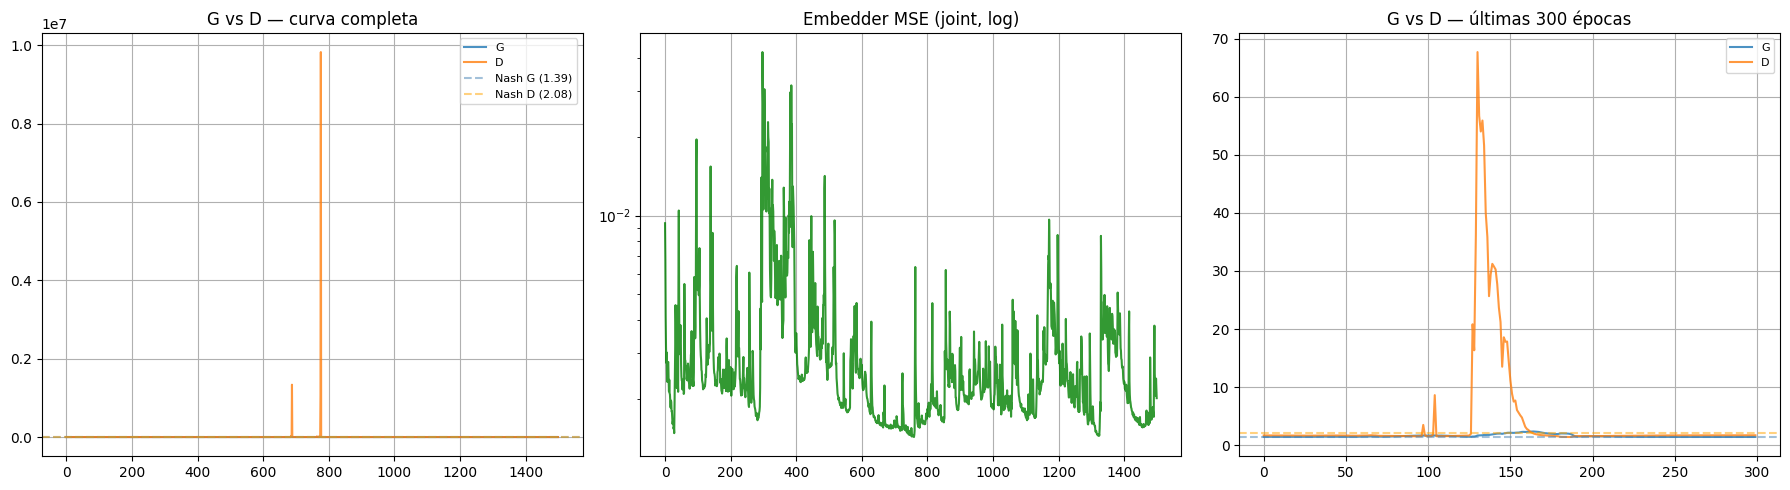

G epoch 1:   1.1186
G epoch 100: 1.3725
G final:     1.3952 | Nash G: 1.3863
D final:     1.6859 | Nash D: 2.0794
Spikes G>3.5: 13 (v7: 287, v6: 26)

✅  Convergencia al Nash


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D — curva completa")
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (joint, log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes   = sum(1 for g in joint_g_history if g > 3.5)
g_100    = joint_g_history[99] if len(joint_g_history) >= 100 else joint_g_history[-1]
g_init   = joint_g_history[0]

print(f"G epoch 1:   {g_init:.4f}")
print(f"G epoch 100: {g_100:.4f}")
print(f"G final:     {g_f:.4f} | Nash G: {nash_g:.4f}")
print(f"D final:     {d_f:.4f} | Nash D: {nash_d:.4f}")
print(f"Spikes G>3.5: {spikes} (v7: 287, v6: 26)")
print()

if g_100 < g_init - 0.1:
    print("✅  G bajó en las primeras 100 épocas — el QuantileTransformer funcionó")
elif abs(g_100 - g_init) < 0.05:
    print("❌  G sigue plano — el mismatch distribucional persiste")
    print("   Verificar: ¿el % de ceros en los datos fue < 0.5%?")

if g_f < 1.8:
    print("✅  Convergencia al Nash")
elif g_f < 2.0:
    print("⚠️  Cerca del Nash — mejora significativa")
elif g_f < 2.15:
    print("⚠️  Mejora parcial respecto a v7 (2.22)")
else:
    print("❌  G sigue en zona de colapso")


## Generación y síntesis completa


In [19]:
n_synth = len(train_windows)
synth_qt_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)

# En espacio QT (≈ uniforme [0,1])
# Recovery es lineal — puede salir ligeramente de [0,1], clipeamos solo si es necesario
synth_qt = np.concatenate(synth_qt_list, axis=0)
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")

# Clipear solo si hay valores muy fuera de rango (indica que el modelo no convergió)
out_of_range = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Fracción fuera de [-0.1, 1.1]: {out_of_range:.2f}%")
if out_of_range < 1.0:
    print("✅  El generador está en el rango correcto")
else:
    print("⚠️  El generador produce valores fuera de rango — posible no convergencia")

synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

diff_mean = abs(train_windows.mean() - synth_qt_clipped.mean())
diff_std  = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"\nDiff medias: {diff_mean:.4f} (v7: 0.1420, v6: 0.1744)")
print(f"Diff stds:   {diff_std:.4f}")


Rango pre-clip: [-0.0921, 1.1006]
Fracción fuera de [-0.1, 1.1]: 0.00%
✅  El generador está en el rango correcto

Diff medias: 0.0986 (v7: 0.1420, v6: 0.1744)
Diff stds:   0.0597


In [20]:
# Inverse transform: espacio QT → escala física
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

# Síntesis empírica de FITs
def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p_zero = fit_empirical[col]["p_zero"]
        flows  = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p_zero else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p_zero else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(flows))
    return windows

synth_fit_raw = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED)

# Síntesis empírica de discretas
def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp = disc_empirical[col]; vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i, t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

# Construir array completo de continuas para el detector
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

synth_for_det = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes finales:")
print(f"  synth_qt_clipped:  {synth_qt_clipped.shape}")
print(f"  synth_gan_phys:    {synth_gan_phys.shape}")
print(f"  synth_fit_raw:     {synth_fit_raw.shape}")
print(f"  synth_for_det:     {synth_for_det.shape}")


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


Shapes finales:
  synth_qt_clipped:  (3784, 60, 14)
  synth_gan_phys:    (3784, 60, 14)
  synth_fit_raw:     (3784, 60, 9)
  synth_for_det:     (3784, 60, 23)


In [21]:
def one_hot_encode_ds(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]; oh = np.zeros(len(cats), dtype=np.float32)
            v = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_encode_ds(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape, "| X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60) | X_synth_disc: (3784, 104)


## Evaluación PCA, t-SNE y AUC


Diff medias: 0.1579 | Diff stds: 0.1477


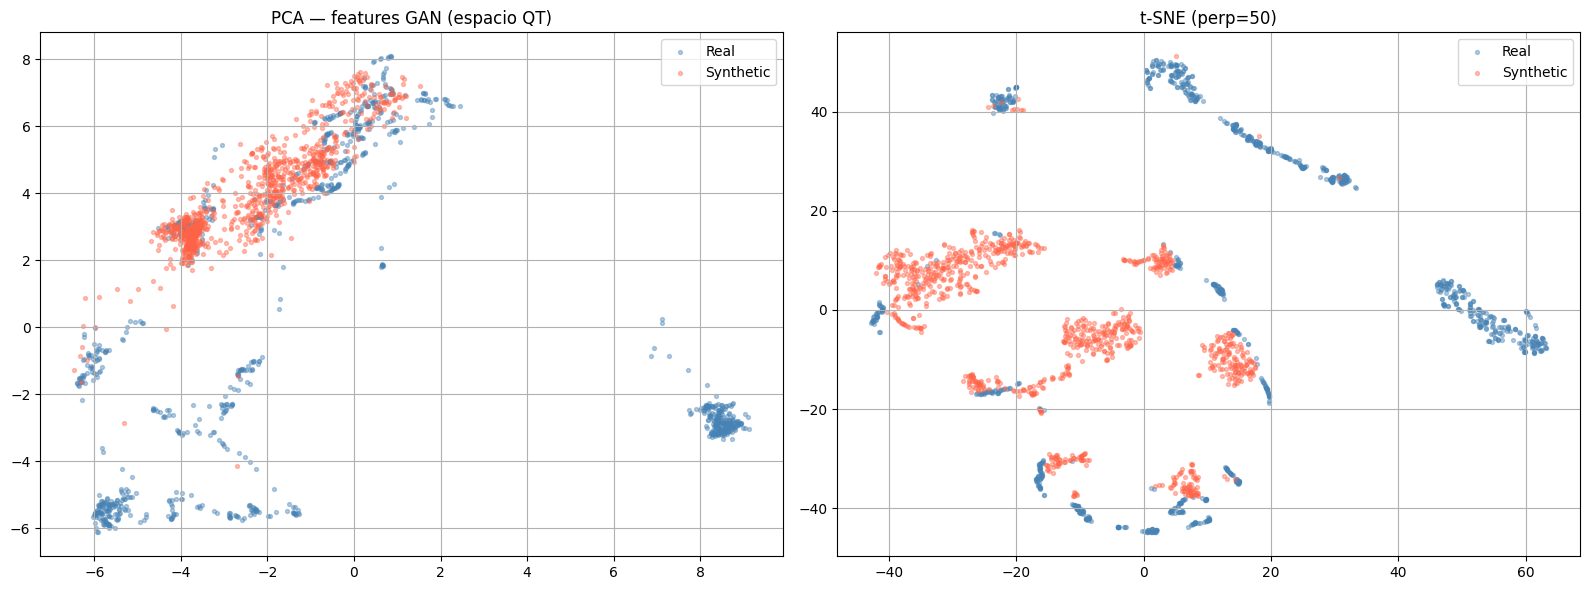

In [22]:
n_plot = min(1000, len(train_windows), len(synth_qt_clipped))
rng = np.random.default_rng(SEED)
ri  = rng.choice(len(train_windows),      n_plot, replace=False)
si  = rng.choice(len(synth_qt_clipped),   n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()
print(f"Diff medias: {md:.4f} | Diff stds: {sd:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca = PCA(n_components=2, random_state=SEED)
pr  = pca.fit_transform(real_s); ps = pca.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — features GAN (espacio QT)")
axes[0].legend(); axes[0].grid(True)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp})")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig("tsne_v8.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC = {auc:.4f}")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("⚠️  0.60–0.75 — Aceptable")
elif auc < 0.85: print("⚠️  0.75–0.85 — Mejora vs v7 (1.0)")
else:            print("❌  > 0.85 — G loss sigue en zona de colapso")
print("=" * 50)

fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]} t={ti}: {fi[i]:.4f}")

max_imp = fi.max()
if max_imp > 0.10:
    print(f"\n⚠️  Una feature tiene importancia {max_imp:.3f} — revisar su distribución post-QT")
else:
    print(f"\n✅  Importancias distribuidas — ninguna feature domina")


AUC = 0.9997
❌  > 0.85 — G loss sigue en zona de colapso

Top 5 features más discriminativas:
  PIT501.Pv t=25: 0.0252
  PIT503.Pv t=45: 0.0215
  AIT503.Pv t=49: 0.0213
  PIT503.Pv t=31: 0.0212
  LIT401.Pv t=15: 0.0212

✅  Importancias distribuidas — ninguna feature domina


## Guardado


In [24]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(qt,                   PROJECT_ROOT / "artifacts" / "scalers" / "timegan_quantile_transformer.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "fit_empirical.json", "w") as f:
    json.dump({
        col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
        for col, v in fit_empirical.items()
    }, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk, vv in v.items()} for k, v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=2)

config = {
    "version": "v8",
    "key_fix": "QuantileTransformer(uniform) — elimina mismatch distribucional GAN",
    "gan_cont_cols": GAN_CONT_COLS, "fit_cols_empirical": FIT_COLS,
    "continuous_cols_detector": continuous_cols, "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "scaler_timegan": "QuantileTransformer(n_quantiles=1000, output_distribution=uniform)",
    "feature_dim_gan": feature_dim, "hidden_dim": hidden_dim, "latent_dim": latent_dim,
    "num_layers": num_layers, "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r, "lambda_s": lambda_s,
    "embedder_mse_final": float(embedder_history[-1]),
    "g_loss_final": float(joint_g_history[-1]),
    "d_loss_final": float(joint_d_history[-1]),
    "g_spikes": int(sum(1 for g in joint_g_history if g > 3.5)),
    "auc_gan": float(auc), "diff_medias": float(md), "diff_stds": float(sd),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f: json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synth_qt.npy",          synth_qt_clipped)
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Guardado en:", TIMEGAN_MODEL_DIR.resolve())


✅  Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
